<a href="https://colab.research.google.com/github/iclalsonmez/task-aware-adaptive-quantization/blob/main/data_compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-Aware Adaptive Quantization for Fashion-MNIST Image Compression

This notebook presents a task-aware image compression experiment on the Fashion-MNIST dataset. The main goal is to compare uniform DCT-based quantization with adaptive quantization strategies that change the quantization strength according to local image content.

The project evaluates compression not only with traditional image quality metrics, but also with classification accuracy. In this way, the experiment investigates whether compressed images still preserve task-relevant visual information after reconstruction.

## Compared Methods

1. Original images
2. Uniform DCT quantization
3. Adaptive DCT quantization with two different parameter settings

## Evaluation Metrics

- Mean Squared Error (MSE)
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index Measure (SSIM)
- Estimated Compression Ratio
- Classification Accuracy
- Processing Time

## 1. Environment Setup

In [1]:
import torch
import platform
import sys

print("Python version:", sys.version)
print("Platform:", platform.platform())
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [2]:
import os
import time
import math
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

## 2. Dataset Preparation

Fashion-MNIST is used as the test dataset because it is small, clean, and suitable for both image compression and classification-based evaluation. Each image is a 28x28 grayscale image belonging to one of ten clothing categories.

To keep the experiment fast and reproducible, a subset of the full dataset is used.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = 20000
test_size = 5000

train_indices = np.random.choice(len(train_dataset_full), train_size, replace=False)
test_indices = np.random.choice(len(test_dataset_full), test_size, replace=False)

train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

batch_size = 256

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 26.4M/26.4M [00:00<00:00, 115MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.44MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.0MB/s]


Train samples: 20000
Test samples: 5000


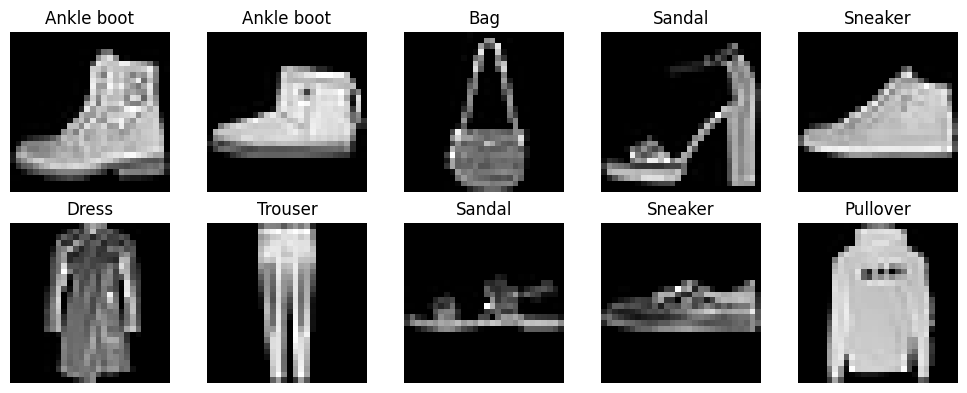

In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Baseline CNN Classifier

A small convolutional neural network is trained on the original Fashion-MNIST images. The goal is not to build the best possible classifier, but to obtain a baseline model that can later be used to measure how much task-relevant information is preserved after compression.

In [6]:
class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SmallCNN().to(device)
print(model)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 3

history = []

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc
    })

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}"
    )

end_time = time.time()
print(f"\nTraining time: {end_time - start_time:.2f} seconds")

history_df = pd.DataFrame(history)
history_df

Epoch [1/3] Train Loss: 0.9505 | Train Acc: 0.6675 Test Loss: 0.5809 | Test Acc: 0.7802
Epoch [2/3] Train Loss: 0.5188 | Train Acc: 0.8075 Test Loss: 0.4664 | Test Acc: 0.8304
Epoch [3/3] Train Loss: 0.4287 | Train Acc: 0.8471 Test Loss: 0.4087 | Test Acc: 0.8528

Training time: 11.51 seconds


,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.950488,0.6675,0.580883,0.7802
1,2,0.518788,0.8075,0.466442,0.8304
2,3,0.428709,0.8471,0.408674,0.8528


In [9]:
baseline_loss, baseline_acc = evaluate(model, test_loader, criterion, device)

print("Baseline Test Loss:", baseline_loss)
print("Baseline Test Accuracy:", baseline_acc)

Baseline Test Loss: 0.40867377204895017
Baseline Test Accuracy: 0.8528


## 4. DCT-Based Compression Utilities

Fashion-MNIST images have a size of 28x28 pixels. Since the DCT compression pipeline works with 8x8 blocks, each image is temporarily padded to 32x32. After reconstruction, the image is cropped back to 28x28.

The compression ratio used in this notebook is an estimated compression ratio based on the sparsity of quantized DCT coefficients. It does not represent a final entropy-coded file size, but it provides a consistent proxy for comparing different quantization strategies.

In [10]:
def pad_to_32(img):
    padded = np.zeros((32, 32), dtype=np.float32)
    padded[:28, :28] = img
    return padded


def crop_to_28(img):
    return img[:28, :28]


def mse_metric(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)


def psnr_metric(original, reconstructed, max_pixel=1.0):
    mse = mse_metric(original, reconstructed)
    if mse == 0:
        return float("inf")
    return 20 * np.log10(max_pixel / np.sqrt(mse))


def ssim_metric(original, reconstructed):
    return ssim(original, reconstructed, data_range=1.0)


def estimate_compression_ratio(quantized_blocks):
    total_coeffs = quantized_blocks.size
    nonzero_coeffs = np.count_nonzero(quantized_blocks)

    if nonzero_coeffs == 0:
        return total_coeffs

    return total_coeffs / nonzero_coeffs

## 5. Uniform DCT Quantization

In uniform quantization, the same quantization parameter is applied to all 8x8 DCT blocks. This is used as the baseline compression method.

In [11]:
def uniform_dct_quantization(img, q=0.10):
    """
    Applies uniform DCT-based quantization to an input image.

    The image is padded to 32x32, divided into 8x8 blocks,
    transformed with DCT, quantized using a single q value,
    and reconstructed with inverse DCT.
    """
    img_32 = pad_to_32(img)
    reconstructed = np.zeros_like(img_32, dtype=np.float32)
    quantized_all = np.zeros_like(img_32, dtype=np.float32)

    for i in range(0, 32, 8):
        for j in range(0, 32, 8):
            block = img_32[i:i+8, j:j+8].astype(np.float32)

            dct_block = cv2.dct(block)
            quantized = np.round(dct_block / q)
            dequantized = quantized * q
            idct_block = cv2.idct(dequantized)

            reconstructed[i:i+8, j:j+8] = idct_block
            quantized_all[i:i+8, j:j+8] = quantized

    reconstructed = crop_to_28(reconstructed)
    reconstructed = np.clip(reconstructed, 0, 1)

    cr = estimate_compression_ratio(quantized_all)
    mse = mse_metric(img, reconstructed)
    psnr = psnr_metric(img, reconstructed)
    ssim_score = ssim_metric(img, reconstructed)

    return reconstructed, mse, psnr, ssim_score, cr

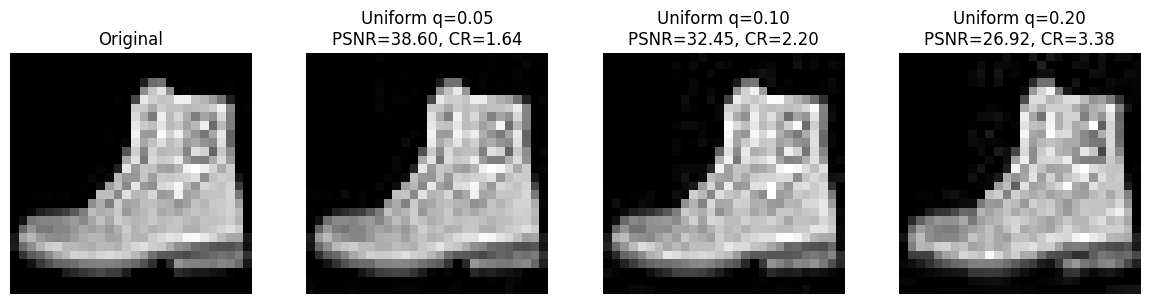

In [12]:
sample_img = images[0].squeeze().numpy().astype(np.float32)

uniform_rec_5, mse_5, psnr_5, ssim_5, cr_5 = uniform_dct_quantization(sample_img, q=0.05)
uniform_rec_10, mse_10, psnr_10, ssim_10, cr_10 = uniform_dct_quantization(sample_img, q=0.10)
uniform_rec_20, mse_20, psnr_20, ssim_20, cr_20 = uniform_dct_quantization(sample_img, q=0.20)

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.imshow(sample_img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(uniform_rec_5, cmap="gray")
plt.title(f"Uniform q=0.05\nPSNR={psnr_5:.2f}, CR={cr_5:.2f}")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(uniform_rec_10, cmap="gray")
plt.title(f"Uniform q=0.10\nPSNR={psnr_10:.2f}, CR={cr_10:.2f}")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(uniform_rec_20, cmap="gray")
plt.title(f"Uniform q=0.20\nPSNR={psnr_20:.2f}, CR={cr_20:.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Content-Aware Adaptive Quantization

The adaptive method changes the quantization strength according to the local content of each 8x8 block. Block variance is used as a simple content-awareness criterion.

- High-variance blocks are treated as visually important and compressed less aggressively.
- Medium-variance blocks receive a medium quantization level.
- Low-variance blocks are treated as smoother regions and compressed more aggressively.

Two adaptive settings are tested:

- **Adaptive A:** More quality-preserving setting.
- **Adaptive B:** More aggressive setting designed to move closer to the compression ratio of uniform quantization.

In [13]:
def adaptive_dct_quantization(img, q_low=0.05, q_mid=0.10, q_high=0.20, debug=False):
    """
    Applies adaptive DCT-based quantization using block variance.

    High-variance blocks use q_low.
    Medium-variance blocks use q_mid.
    Low-variance blocks use q_high.
    """
    img_32 = pad_to_32(img)
    reconstructed = np.zeros_like(img_32, dtype=np.float32)
    quantized_all = np.zeros_like(img_32, dtype=np.float32)

    variances = []

    for i in range(0, 32, 8):
        for j in range(0, 32, 8):
            block = img_32[i:i+8, j:j+8].astype(np.float32)
            variances.append(float(np.var(block)))

    low_thr = np.percentile(variances, 33)
    high_thr = np.percentile(variances, 66)

    q_map = np.zeros((4, 4), dtype=np.float32)

    for bi, i in enumerate(range(0, 32, 8)):
        for bj, j in enumerate(range(0, 32, 8)):
            block = img_32[i:i+8, j:j+8].astype(np.float32)
            block_var = float(np.var(block))

            if block_var >= high_thr:
                q = q_low
            elif block_var >= low_thr:
                q = q_mid
            else:
                q = q_high

            dct_block = cv2.dct(block)
            quantized = np.round(dct_block / q)
            dequantized = quantized * q
            idct_block = cv2.idct(dequantized)

            reconstructed[i:i+8, j:j+8] = idct_block
            quantized_all[i:i+8, j:j+8] = quantized
            q_map[bi, bj] = q

    reconstructed = crop_to_28(reconstructed)
    reconstructed = np.clip(reconstructed, 0, 1)

    cr = estimate_compression_ratio(quantized_all)
    mse = mse_metric(img, reconstructed)
    psnr = psnr_metric(img, reconstructed)
    ssim_score = ssim_metric(img, reconstructed)

    if debug:
        print("Block variances:", variances)
        print("Low threshold:", low_thr)
        print("High threshold:", high_thr)
        print("Q map:\n", q_map)

    return reconstructed, mse, psnr, ssim_score, cr, q_map

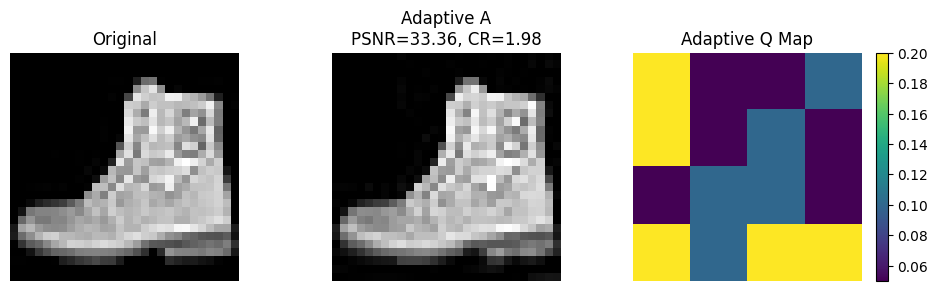

Adaptive MSE: 0.00046155602
Adaptive PSNR: 33.357758
Adaptive SSIM: 0.9799354468002792
Adaptive Estimated CR: 1.9768339768339769
Q Map:
[[0.2  0.05 0.05 0.1 ]
 [0.2  0.05 0.1  0.05]
 [0.05 0.1  0.1  0.05]
 [0.2  0.1  0.2  0.2 ]]


In [14]:
adaptive_rec, adaptive_mse, adaptive_psnr, adaptive_ssim, adaptive_cr, q_map = adaptive_dct_quantization(
    sample_img,
    q_low=0.05,
    q_mid=0.10,
    q_high=0.20
)

plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.imshow(sample_img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adaptive_rec, cmap="gray")
plt.title(f"Adaptive A\nPSNR={adaptive_psnr:.2f}, CR={adaptive_cr:.2f}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(q_map)
plt.title("Adaptive Q Map")
plt.colorbar()
plt.axis("off")

plt.tight_layout()
plt.show()

print("Adaptive MSE:", adaptive_mse)
print("Adaptive PSNR:", adaptive_psnr)
print("Adaptive SSIM:", adaptive_ssim)
print("Adaptive Estimated CR:", adaptive_cr)
print("Q Map:")
print(q_map)

## 7. Evaluation on the Test Set

The trained classifier is evaluated on original and reconstructed test images. This allows the experiment to measure whether compressed images still preserve class-related visual information.

In [15]:
def compress_dataset(dataset, method="uniform", q=0.10, q_low=0.05, q_mid=0.10, q_high=0.20, max_samples=None):
    compressed_images = []
    labels_list = []

    mse_values = []
    psnr_values = []
    ssim_values = []
    cr_values = []

    n = len(dataset) if max_samples is None else min(len(dataset), max_samples)

    start = time.time()

    for idx in range(n):
        img_tensor, label = dataset[idx]
        img = img_tensor.squeeze().numpy().astype(np.float32)

        if method == "uniform":
            rec, mse, psnr, ssim_score, cr = uniform_dct_quantization(img, q=q)

        elif method == "adaptive":
            rec, mse, psnr, ssim_score, cr, _ = adaptive_dct_quantization(
                img,
                q_low=q_low,
                q_mid=q_mid,
                q_high=q_high
            )

        else:
            raise ValueError("method must be 'uniform' or 'adaptive'")

        compressed_images.append(rec)
        labels_list.append(label)

        mse_values.append(mse)
        psnr_values.append(psnr)
        ssim_values.append(ssim_score)
        cr_values.append(cr)

    compressed_images = np.array(compressed_images, dtype=np.float32)
    compressed_images = torch.tensor(compressed_images).unsqueeze(1)

    labels_tensor = torch.tensor(labels_list, dtype=torch.long)

    compressed_dataset = TensorDataset(compressed_images, labels_tensor)

    elapsed = time.time() - start

    metrics = {
        "method": method,
        "avg_mse": float(np.mean(mse_values)),
        "avg_psnr": float(np.mean(psnr_values)),
        "avg_ssim": float(np.mean(ssim_values)),
        "estimated_cr": float(np.mean(cr_values)),
        "elapsed_sec": elapsed
    }

    return compressed_dataset, metrics

In [16]:
uniform_q10_dataset, uniform_q10_metrics = compress_dataset(
    test_dataset,
    method="uniform",
    q=0.10
)

uniform_q20_dataset, uniform_q20_metrics = compress_dataset(
    test_dataset,
    method="uniform",
    q=0.20
)

adaptive_a_dataset, adaptive_a_metrics = compress_dataset(
    test_dataset,
    method="adaptive",
    q_low=0.05,
    q_mid=0.10,
    q_high=0.20
)

adaptive_b_dataset, adaptive_b_metrics = compress_dataset(
    test_dataset,
    method="adaptive",
    q_low=0.08,
    q_mid=0.14,
    q_high=0.25
)

print("Uniform Quantization q=0.10:", uniform_q10_metrics)
print("Uniform Quantization q=0.20:", uniform_q20_metrics)
print("Adaptive Quantization A:", adaptive_a_metrics)
print("Adaptive Quantization B:", adaptive_b_metrics)

Uniform Quantization q=0.10: {'method': 'uniform', 'avg_mse': 0.0004622990672942251, 'avg_psnr': 33.49048614501953, 'avg_ssim': 0.9567127269735453, 'estimated_cr': 3.0032959039135285, 'elapsed_sec': 4.7133355140686035}
Uniform Quantization q=0.20: {'method': 'uniform', 'avg_mse': 0.001595345209352672, 'avg_psnr': 28.127683639526367, 'avg_ssim': 0.9041949390535435, 'estimated_cr': 4.684116353535761, 'elapsed_sec': 4.644224405288696}
Adaptive Quantization A: {'method': 'adaptive', 'avg_mse': 0.0003661015653051436, 'avg_psnr': 35.17662048339844, 'avg_ssim': 0.9621329068230942, 'estimated_cr': 2.589404724695726, 'elapsed_sec': 11.215648412704468}
Adaptive Quantization B: {'method': 'adaptive', 'avg_mse': 0.0006531727849505842, 'avg_psnr': 32.42573928833008, 'avg_ssim': 0.9435392340897806, 'estimated_cr': 3.0979117779919267, 'elapsed_sec': 11.156277418136597}


In [17]:
uniform_q10_loader = DataLoader(
    uniform_q10_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

uniform_q20_loader = DataLoader(
    uniform_q20_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

adaptive_a_loader = DataLoader(
    adaptive_a_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

adaptive_b_loader = DataLoader(
    adaptive_b_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [18]:
uniform_q10_loss, uniform_q10_acc = evaluate(
    model,
    uniform_q10_loader,
    criterion,
    device
)

uniform_q20_loss, uniform_q20_acc = evaluate(
    model,
    uniform_q20_loader,
    criterion,
    device
)

adaptive_a_loss, adaptive_a_acc = evaluate(
    model,
    adaptive_a_loader,
    criterion,
    device
)

adaptive_b_loss, adaptive_b_acc = evaluate(
    model,
    adaptive_b_loader,
    criterion,
    device
)

print("Original Accuracy:", baseline_acc)
print("Uniform Quantization q=0.10 Accuracy:", uniform_q10_acc)
print("Uniform Quantization q=0.20 Accuracy:", uniform_q20_acc)
print("Adaptive Quantization A Accuracy:", adaptive_a_acc)
print("Adaptive Quantization B Accuracy:", adaptive_b_acc)

Original Accuracy: 0.8528
Uniform Quantization q=0.10 Accuracy: 0.8522
Uniform Quantization q=0.20 Accuracy: 0.8486
Adaptive Quantization A Accuracy: 0.8526
Adaptive Quantization B Accuracy: 0.8498


In [19]:
results = [
    {
        "Method": "Original",
        "Avg MSE": 0.0,
        "Avg PSNR": np.inf,
        "Avg SSIM": 1.0,
        "Estimated Compression Ratio": 1.0,
        "Accuracy": baseline_acc,
        "Processing Time (s)": 0.0
    },
    {
        "Method": "Uniform Quantization q=0.10",
        "Avg MSE": uniform_q10_metrics["avg_mse"],
        "Avg PSNR": uniform_q10_metrics["avg_psnr"],
        "Avg SSIM": uniform_q10_metrics["avg_ssim"],
        "Estimated Compression Ratio": uniform_q10_metrics["estimated_cr"],
        "Accuracy": uniform_q10_acc,
        "Processing Time (s)": uniform_q10_metrics["elapsed_sec"]
    },
    {
        "Method": "Uniform Quantization q=0.20",
        "Avg MSE": uniform_q20_metrics["avg_mse"],
        "Avg PSNR": uniform_q20_metrics["avg_psnr"],
        "Avg SSIM": uniform_q20_metrics["avg_ssim"],
        "Estimated Compression Ratio": uniform_q20_metrics["estimated_cr"],
        "Accuracy": uniform_q20_acc,
        "Processing Time (s)": uniform_q20_metrics["elapsed_sec"]
    },
    {
        "Method": "Adaptive Quantization A",
        "Avg MSE": adaptive_a_metrics["avg_mse"],
        "Avg PSNR": adaptive_a_metrics["avg_psnr"],
        "Avg SSIM": adaptive_a_metrics["avg_ssim"],
        "Estimated Compression Ratio": adaptive_a_metrics["estimated_cr"],
        "Accuracy": adaptive_a_acc,
        "Processing Time (s)": adaptive_a_metrics["elapsed_sec"]
    },
    {
        "Method": "Adaptive Quantization B",
        "Avg MSE": adaptive_b_metrics["avg_mse"],
        "Avg PSNR": adaptive_b_metrics["avg_psnr"],
        "Avg SSIM": adaptive_b_metrics["avg_ssim"],
        "Estimated Compression Ratio": adaptive_b_metrics["estimated_cr"],
        "Accuracy": adaptive_b_acc,
        "Processing Time (s)": adaptive_b_metrics["elapsed_sec"]
    }
]

results_df = pd.DataFrame(results)
results_df

,Method,Avg MSE,Avg PSNR,Avg SSIM,Estimated Compression Ratio,Accuracy,Processing Time (s)
0,Original,0.000000,inf,1.000000,1.000000,0.8528,0.000000
1,Uniform Quantization q=0.10,0.000462,33.490486,0.956713,3.003296,0.8522,4.713336
2,Uniform Quantization q=0.20,0.001595,28.127684,0.904195,4.684116,0.8486,4.644224
3,Adaptive Quantization A,0.000366,35.176620,0.962133,2.589405,0.8526,11.215648
4,Adaptive Quantization B,0.000653,32.425739,0.943539,3.097912,0.8498,11.156277


## 8. Results and Visualizations

In [20]:
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

results_display = results_df.copy()

results_display["Avg MSE"] = results_display["Avg MSE"].round(6)
results_display["Avg SSIM"] = results_display["Avg SSIM"].round(4)
results_display["Estimated Compression Ratio"] = results_display["Estimated Compression Ratio"].round(3)
results_display["Accuracy"] = results_display["Accuracy"].round(4)
results_display["Processing Time (s)"] = results_display["Processing Time (s)"].round(2)

results_display["Avg PSNR"] = results_display["Avg PSNR"].apply(
    lambda x: "N/A" if np.isinf(x) else round(x, 3)
)

results_df.to_csv("results/compression_results_raw.csv", index=False)
results_display.to_csv("results/compression_results_display.csv", index=False)

results_display

,Method,Avg MSE,Avg PSNR,Avg SSIM,Estimated Compression Ratio,Accuracy,Processing Time (s)
0,Original,0.000000,N/A,1.0000,1.000,0.8528,0.00
1,Uniform Quantization q=0.10,0.000462,33.49,0.9567,3.003,0.8522,4.71
2,Uniform Quantization q=0.20,0.001595,28.128,0.9042,4.684,0.8486,4.64
3,Adaptive Quantization A,0.000366,35.177,0.9621,2.589,0.8526,11.22
4,Adaptive Quantization B,0.000653,32.426,0.9435,3.098,0.8498,11.16


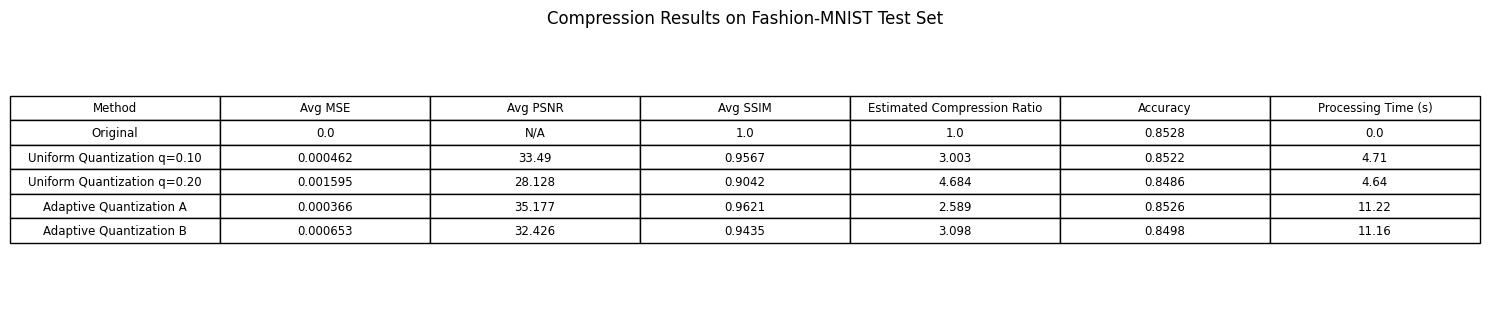

In [21]:
fig, ax = plt.subplots(figsize=(15, 3.2))
ax.axis("off")

table = ax.table(
    cellText=results_display.values,
    colLabels=results_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.4)

plt.title("Compression Results on Fashion-MNIST Test Set", fontsize=12, pad=12)
plt.tight_layout()

plt.savefig("figures/results_table.png", dpi=300, bbox_inches="tight")
plt.show()

### PSNR Comparison

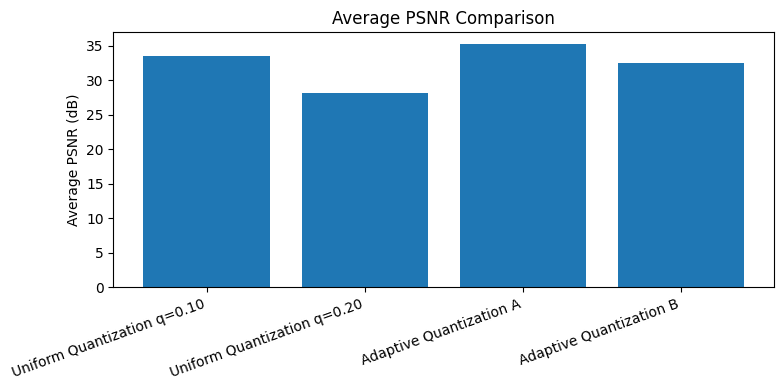

In [22]:
plot_df = results_display.copy()
plot_df_no_original = plot_df[plot_df["Method"] != "Original"].copy()

plt.figure(figsize=(8, 4))
plt.bar(plot_df_no_original["Method"], plot_df_no_original["Avg PSNR"])
plt.ylabel("Average PSNR (dB)")
plt.title("Average PSNR Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/psnr_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Compression Ratio Comparison

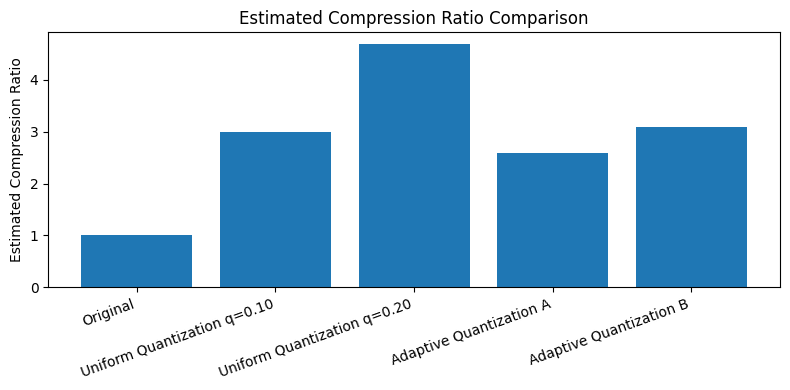

In [23]:
plt.figure(figsize=(8, 4))
plt.bar(plot_df["Method"], plot_df["Estimated Compression Ratio"])
plt.ylabel("Estimated Compression Ratio")
plt.title("Estimated Compression Ratio Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/compression_ratio_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### Classification Accuracy Comparison

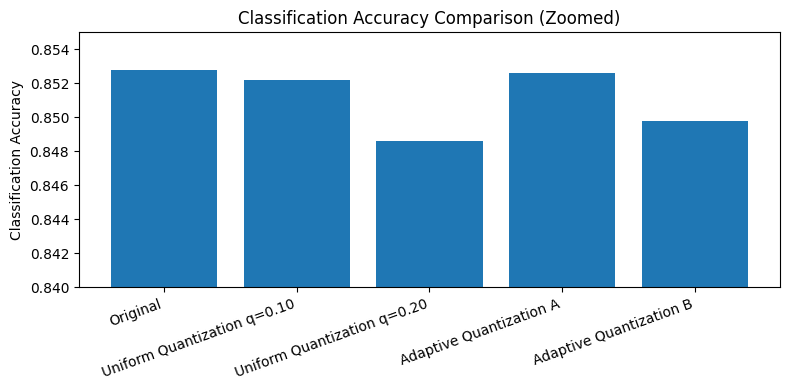

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(plot_df["Method"], plot_df["Accuracy"])
plt.ylabel("Classification Accuracy")
plt.title("Classification Accuracy Comparison (Zoomed)")
plt.ylim(0.84, 0.855)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### PSNR and Compression Trade-off

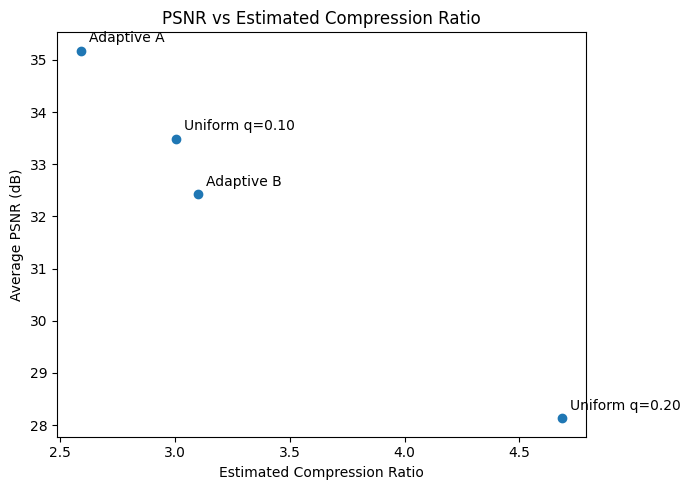

In [25]:
tradeoff_df = results_df[results_df["Method"] != "Original"].copy()

plt.figure(figsize=(7, 5))
plt.scatter(
    tradeoff_df["Estimated Compression Ratio"],
    tradeoff_df["Avg PSNR"]
)

for _, row in tradeoff_df.iterrows():
    plt.annotate(
        row["Method"].replace(" Quantization", ""),
        (row["Estimated Compression Ratio"], row["Avg PSNR"]),
        textcoords="offset points",
        xytext=(6, 6),
        ha="left"
    )

plt.xlabel("Estimated Compression Ratio")
plt.ylabel("Average PSNR (dB)")
plt.title("PSNR vs Estimated Compression Ratio")
plt.tight_layout()
plt.savefig("figures/psnr_vs_compression_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

### Visual Comparison of Reconstructed Images

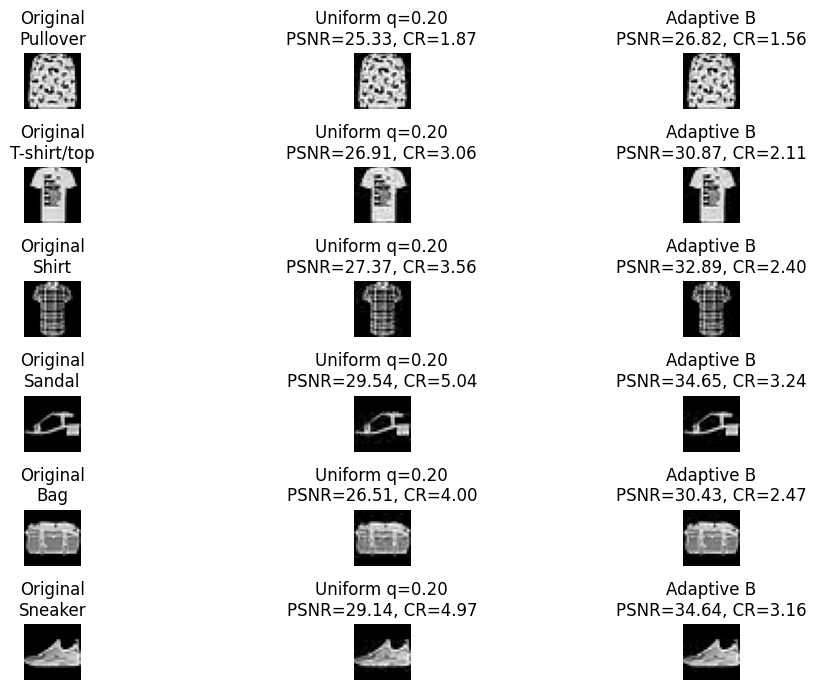

In [26]:
num_examples = 6

plt.figure(figsize=(12, 7))

for idx in range(num_examples):
    img_tensor, label = test_dataset[idx]
    img = img_tensor.squeeze().numpy().astype(np.float32)

    uniform_rec, uniform_mse, uniform_psnr, uniform_ssim, uniform_cr = uniform_dct_quantization(
        img,
        q=0.20
    )

    adaptive_rec, adaptive_mse, adaptive_psnr, adaptive_ssim, adaptive_cr, q_map = adaptive_dct_quantization(
        img,
        q_low=0.08,
        q_mid=0.14,
        q_high=0.25
    )

    plt.subplot(num_examples, 3, idx * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Original\n{class_names[label]}")
    plt.axis("off")

    plt.subplot(num_examples, 3, idx * 3 + 2)
    plt.imshow(uniform_rec, cmap="gray")
    plt.title(f"Uniform q=0.20\nPSNR={uniform_psnr:.2f}, CR={uniform_cr:.2f}")
    plt.axis("off")

    plt.subplot(num_examples, 3, idx * 3 + 3)
    plt.imshow(adaptive_rec, cmap="gray")
    plt.title(f"Adaptive B\nPSNR={adaptive_psnr:.2f}, CR={adaptive_cr:.2f}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("figures/original_uniform_adaptive_examples.png", dpi=300, bbox_inches="tight")
plt.show()

### Adaptive Quantization Maps

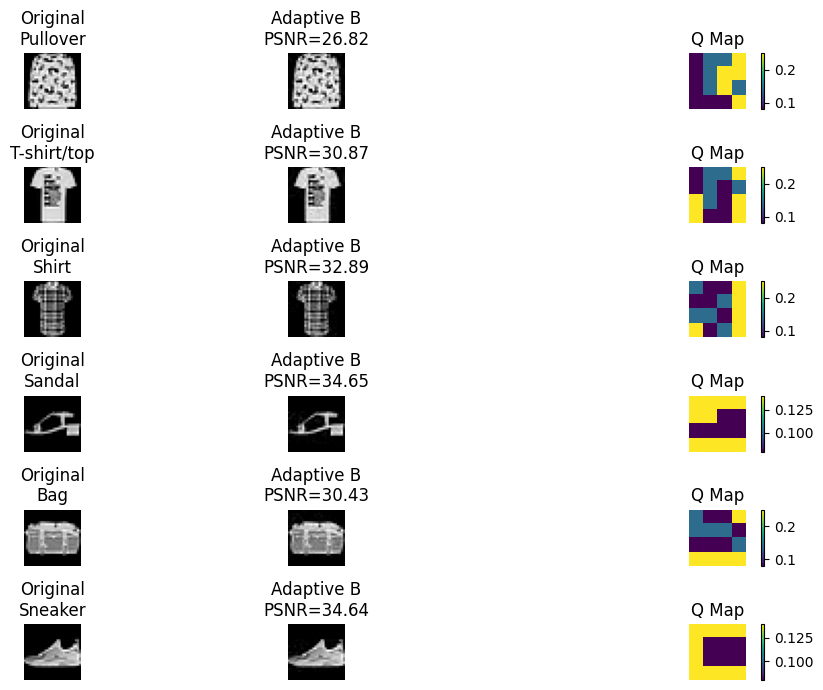

In [27]:
num_examples = 6

plt.figure(figsize=(10, 7))

for idx in range(num_examples):
    img_tensor, label = test_dataset[idx]
    img = img_tensor.squeeze().numpy().astype(np.float32)

    adaptive_rec, adaptive_mse, adaptive_psnr, adaptive_ssim, adaptive_cr, q_map = adaptive_dct_quantization(
        img,
        q_low=0.08,
        q_mid=0.14,
        q_high=0.25
    )

    plt.subplot(num_examples, 3, idx * 3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Original\n{class_names[label]}")
    plt.axis("off")

    plt.subplot(num_examples, 3, idx * 3 + 2)
    plt.imshow(adaptive_rec, cmap="gray")
    plt.title(f"Adaptive B\nPSNR={adaptive_psnr:.2f}")
    plt.axis("off")

    plt.subplot(num_examples, 3, idx * 3 + 3)
    plt.imshow(q_map)
    plt.title("Q Map")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

plt.tight_layout()
plt.savefig("figures/adaptive_q_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Discussion

The results show a clear trade-off between compression ratio and reconstructed image quality. Uniform Quantization with q=0.20 achieved the highest estimated compression ratio, but it also produced the lowest PSNR and SSIM values. This indicates that stronger uniform quantization increases compression, but removes more visual detail from the images.

Uniform Quantization with q=0.10 provided a more balanced baseline. It preserved image quality better than q=0.20, but it still applied the same quantization level to every 8x8 block without considering local image content.

The adaptive methods used block variance to select different quantization levels for different image regions. Adaptive Quantization A preserved the highest image quality among the compressed methods, while Adaptive Quantization B increased the compression ratio with a moderate decrease in PSNR and SSIM. This shows that adaptive quantization is controllable, but also sensitive to the selected q values.

Classification accuracy stayed close to the original baseline for all compressed methods. Therefore, the compressed images still preserved most of the task-relevant visual information. The small accuracy differences should not be interpreted as compression improving classification, but rather as evidence that the compression methods did not severely harm the classification task.

Processing time results show that adaptive quantization is slower than uniform quantization because it computes block-level variance and selects q values separately. Overall, uniform quantization is faster and simpler, while adaptive quantization provides a more flexible content-aware compression strategy.

In [28]:
print("Results files:")
print(os.listdir("results"))

print("\nFigure files:")
print(os.listdir("figures"))

Results files:
['compression_results_display.csv', 'compression_results_raw.csv']

Figure files:
['accuracy_comparison.png', 'original_uniform_adaptive_examples.png', 'compression_ratio_comparison.png', 'results_table.png', 'psnr_vs_compression_ratio.png', 'psnr_comparison.png', 'adaptive_q_maps.png']
